<a href="https://colab.research.google.com/github/williamG7/Reinforced-Learning-amb-Atari-2600/blob/main/Reinforced_Learning_amb_Atari_2600_GuzmanWilliam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje por Refuerzo con Atari 2600

![mario-atari-2066](https://ale.farama.org/_static/videos/environments/mario_bros.gif)
![assault-atari-2066](https://ale.farama.org/_static/videos/environments/assault.gif)
![donkey-kong-atari-2066](https://ale.farama.org/_static/videos/environments/donkey_kong.gif)
![pacman-atari-2066](https://ale.farama.org/_static/videos/environments/pacman.gif)
![et-atari-2066](https://ale.farama.org/_static/videos/environments/et.gif)
![crossbow-atari-2066](https://ale.farama.org/_static/videos/environments/crossbow.gif)


---

# Enunciado


1. **Selección de un entorno de entrenamiento** para un controlador de juego del **Atari 2600** de la siguiente lista: https://ale.farama.org/environments/complete_list/
2. Se instalará la [Gymnasium Interface](https://ale.farama.org/gymnasium-interface/) en Google Colab
3. Se **importará** el entorno del **juego seleccionado**
4. Se describirán los **objetivos del juego**
5. Se demostrará el **dominio de los diferentes inputs de acciones** que puede recibir el agente dentro del juego seleccionado
6. Se realizará una **demo de las acciones disponibles**
7. Se **configurará el entorno** para permitir la **ejecución manual dentro de Colab**, mostrando los resultados de las acciones por pantalla
8. Se **entrenará un agente mediante RL** con el objetivo de obtener la máxima puntuación posible, aplicando recompensas y penalizaciones
9. Se **optimizará el entrenamiento** aplicando las siguientes técnicas: incremento de timesteps, wrappers de Atari, frame stacking, ajuste de hiperparámetros, reward shaping, entre otras
10. Se hará **jugar al agente entrenado**
11. Se documentarán las **conclusiones y aprendizajes** obtenidos durante el desarrollo de la actividad.

> El número de repeticiones y el tiempo total de entrenamiento del agente son factores determinantes en el resultado del aprendizaje.

> A **mayor número de intentos y errores**, **mayor será el aprendizaje obtenido**.

---

## Entorno escogido (juego de Atari 2600)

### **Space Invaders**
Se ha seleccionado el juego Space Invaders. Se trata de uno de los juegos más icónicos del Atari 2600, en el que se controla una nave espacial con el objetivo de disparar a los alienígenas que avanzan antes de que lleguen al suelo.

https://ale.farama.org/environments/space_invaders/


![Space Invaders](https://ale.farama.org/_images/space_invaders.gif)



## Preparar entorno

## Importaciones

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper

gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


1.   Instalar gymnasium

In [ ]:
!pip install gymnasium
!pip install "gymnasium[atari]"
!pip install "gymnasium[accept-rom-license]"
!pip install stable-baselines3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 7.0 MB/s eta 0:00:00


2.   Importar el entorno del juego escogido

In [ ]:
# Creamos el entorno de Space Invaders
env = gym.make("ALE/SpaceInvaders-v5")

# Reiniciamos el entorno y obtenemos:
# obs: la imagen inicial del juego (array de píxeles)
# info: información extra del entorno
obs, info = env.reset()

print("Entorno creado correctamente!")
print("Entorno:", env)
print("Shape de la observación inicial:", obs.shape)

Entorno creado correctamente!
Entorno: <OrderEnforcing<PassiveEnvChecker<AtariEnv<ALE/SpaceInvaders-v5>>>>
Shape de la observación inicial: (210, 160, 3)


## Objetivos del juego

> Se explicará **cómo se consigue puntuación** en el juego seleccionado, cuál es el objetivo final y los posibles desenlaces: las condiciones de victoria y las condiciones de derrota.

Space Invaders es un juego del Atari 2600 donde controlas una nave espacial
que se mueve horizontalmente por la parte inferior de la pantalla.

**Cómo se consigue puntuación:**
- Disparar y eliminar aliens da puntos. Los aliens de las filas superiores
  valen más puntos que los de las filas inferiores.
- Un OVNI rojo aparece ocasionalmente por la parte superior y da
  puntuación extra si lo eliminas.

**Objetivo final:**
Eliminar todas las oleadas de aliens antes de que lleguen al suelo.

**Cómo se gana:**
Eliminando todos los aliens de la pantalla. Aparecen nuevas oleadas
cada vez más rápidas.

**Cómo se pierde:**
- Los aliens llegan a la parte inferior de la pantalla.
- Un alien dispara y elimina tu nave (tienes 3 vidas).

## Tabla de acciones disponibles

A continuación se muestra la tabla de las acciones disponibles del agente dentro del entorno del juego seleccionado.

In [ ]:
# Obtenemos el número total de acciones disponibles
n_acciones = env.action_space.n
print("Número de acciones disponibles:", n_acciones)

# Obtenemos los nombres de cada acción
nombres_acciones = env.unwrapped.get_action_meanings()
print("Acciones disponibles:")
for i, accion in enumerate(nombres_acciones):
    print(f"Accion {i}: {accion}")

Número de acciones disponibles: 6
Acciones disponibles:
Accion 0: NOOP
Accion 1: FIRE
Accion 2: RIGHT
Accion 3: LEFT
Accion 4: RIGHTFIRE
Accion 5: LEFTFIRE


| Acción | Nombre    | Descripción                         |
|--------|-----------|-------------------------------------|
| 0      | NOOP      | No hacer nada (ninguna acción)      |
| 1      | FIRE      | Disparar                            |
| 2      | RIGHT     | Moverse a la derecha                |
| 3      | LEFT      | Moverse a la izquierda              |
| 4      | RIGHTFIRE | Moverse a la derecha y disparar     |
| 5      | LEFTFIRE  | Moverse a la izquierda y disparar   |

## Demo de las acciones disponibles

Mostrar por pantalla el resultado de todas las acciones de input disponibles

In [ ]:
# Reiniciamos el entorno
obs, info = env.reset()

# Ejecutamos cada acción una vez y mostramos el resultado
nombres_acciones = env.unwrapped.get_action_meanings()

for accion in range(env.action_space.n):
    obs, reward, terminated, truncated, info = env.step(accion)
    print(f"Acción {accion} ({nombres_acciones[accion]}): recompensa={reward}, terminado={terminated}")

Acción 0 (NOOP): recompensa=0.0, terminado=False
Acción 1 (FIRE): recompensa=0.0, terminado=False
Acción 2 (RIGHT): recompensa=0.0, terminado=False
Acción 3 (LEFT): recompensa=0.0, terminado=False
Acción 4 (RIGHTFIRE): recompensa=0.0, terminado=False
Acción 5 (LEFTFIRE): recompensa=0.0, terminado=False


## Permitir jugar desde Colab

In [ ]:
nombres_acciones = env.unwrapped.get_action_meanings()
obs, info = env.reset()
puntuacion_total = 0
accion = -1

while accion != 6:
    print("SPACE INVADERS")
    print("Acciones disponibles:")
    for i, nombre in enumerate(nombres_acciones):
        print(f"{i} -> {nombre}")
    print("6 -> Salir")

    try:
        accion = int(input("\n¿Qué acción quieres hacer? (0-5, 6 para salir): "))
    except:
        print("Entrada no válida, usando NOOP")
        accion = 0

    if accion not in range(env.action_space.n):
        if accion != 6:
            print("Acción no válida, usando NOOP")
            accion = 0

    if accion != 6:
        obs, reward, terminated, truncated, info = env.step(accion)
        puntuacion_total += reward
        print(f"Acción: {nombres_acciones[accion]} | Recompensa: {reward} | Puntuación total: {puntuacion_total}\n")

print(f"\nJuego terminado! Puntuación final: {puntuacion_total}")

SPACE INVADERS
Acciones disponibles:
0 -> NOOP
1 -> FIRE
2 -> RIGHT
3 -> LEFT
4 -> RIGHTFIRE
5 -> LEFTFIRE
6 -> Salir

¿Qué acción quieres hacer? (0-5, 6 para salir): 1
Acción: FIRE | Recompensa: 0.0 | Puntuación total: 0.0

SPACE INVADERS
Acciones disponibles:
0 -> NOOP
1 -> FIRE
2 -> RIGHT
3 -> LEFT
4 -> RIGHTFIRE
5 -> LEFTFIRE
6 -> Salir

¿Qué acción quieres hacer? (0-5, 6 para salir): 4
Acción: RIGHTFIRE | Recompensa: 0.0 | Puntuación total: 0.0

SPACE INVADERS
Acciones disponibles:
0 -> NOOP
1 -> FIRE
2 -> RIGHT
3 -> LEFT
4 -> RIGHTFIRE
5 -> LEFTFIRE
6 -> Salir

¿Qué acción quieres hacer? (0-5, 6 para salir): 5
Acción: LEFTFIRE | Recompensa: 0.0 | Puntuación total: 0.0

SPACE INVADERS
Acciones disponibles:
0 -> NOOP
1 -> FIRE
2 -> RIGHT
3 -> LEFT
4 -> RIGHTFIRE
5 -> LEFTFIRE
6 -> Salir

¿Qué acción quieres hacer? (0-5, 6 para salir): 5
Acción: LEFTFIRE | Recompensa: 0.0 | Puntuación total: 0.0

SPACE INVADERS
Acciones disponibles:
0 -> NOOP
1 -> FIRE
2 -> RIGHT
3 -> LEFT
4 -> RIGH

## Entrenar al agente

In [ ]:
# Creamos el entorno con wrappers de Atari para el entrenamiento
env_train = make_atari_env("ALE/SpaceInvaders-v5", n_envs=1, seed=42)

# Apilamos 4 frames seguidos para que el agente perciba movimiento
env_train = VecFrameStack(env_train, n_stack=4)

# Creamos el agente con PPO y política de red neuronal convolucional
modelo = PPO("CnnPolicy", env_train, verbose=1)

# Entrenamos el agente
modelo.learn(total_timesteps=100000)

print("Entrenamiento completado!")

## Optimizar el entrenamiento del agente

In [ ]:
# Entorno optimizado con wrappers de Atari y frame stacking
env_opt = make_atari_env("ALE/SpaceInvaders-v5", n_envs=4, seed=42)
env_opt = VecFrameStack(env_opt, n_stack=4)

# Agente PPO con hiperparámetros mejorados
modelo_opt = PPO(
    "CnnPolicy",
    env_opt,
    n_steps=128,
    batch_size=256,
    n_epochs=4,
    gamma=0.99,
    learning_rate=2.5e-4,
    clip_range=0.1,
    verbose=1
)

# Entrenamos con más timesteps
modelo_opt.learn(total_timesteps=500000)

print("Entrenamiento optimizado completado!")

## El agente entrenado juega al juego

Hacer que el **agente entrenado juegue** al juego hasta que obtenga un mínimo de puntuación e **imprimir por pantalla** la **evolución de la partida gráficamente** y **mostrar el resultado final** al terminar la partida (el agente se queda sin vidas).

In [ ]:
# Creamos un entorno limpio para que juegue el agente
env_test = make_atari_env("ALE/SpaceInvaders-v5", n_envs=1, seed=42)
env_test = VecFrameStack(env_test, n_stack=4)

num_partidas = 50
puntuaciones = []

for partida in range(num_partidas):
    obs = env_test.reset()
    puntuacion_total = 0
    pasos = 0
    done = False

    while done == False:
        accion, _ = modelo_opt.predict(obs, deterministic=True)
        obs, reward, done, info = env_test.step(accion)
        puntuacion_total += reward[0]
        pasos += 1
        done = done[0]

    puntuaciones.append(puntuacion_total)
    print(f"Partida {partida + 1} | Puntuación: {puntuacion_total} | Pasos: {pasos}")

print(f"\nPuntuación media: {sum(puntuaciones) / num_partidas}")
print(f"Mejor partida: {max(puntuaciones)}")
print(f"Peor partida: {min(puntuaciones)}")

Partida 1 | Puntuación: 6.0 | Pasos: 43
Partida 2 | Puntuación: 5.0 | Pasos: 91
Partida 3 | Puntuación: 4.0 | Pasos: 55
Partida 4 | Puntuación: 2.0 | Pasos: 24
Partida 5 | Puntuación: 2.0 | Pasos: 12
Partida 6 | Puntuación: 2.0 | Pasos: 62
Partida 7 | Puntuación: 6.0 | Pasos: 38
Partida 8 | Puntuación: 5.0 | Pasos: 92
Partida 9 | Puntuación: 4.0 | Pasos: 54
Partida 10 | Puntuación: 3.0 | Pasos: 29
Partida 11 | Puntuación: 2.0 | Pasos: 13
Partida 12 | Puntuación: 1.0 | Pasos: 59
Partida 13 | Puntuación: 6.0 | Pasos: 42
Partida 14 | Puntuación: 5.0 | Pasos: 92
Partida 15 | Puntuación: 12.0 | Pasos: 111
Partida 16 | Puntuación: 6.0 | Pasos: 39
Partida 17 | Puntuación: 4.0 | Pasos: 86
Partida 18 | Puntuación: 6.0 | Pasos: 50
Partida 19 | Puntuación: 6.0 | Pasos: 40
Partida 20 | Puntuación: 6.0 | Pasos: 95
Partida 21 | Puntuación: 4.0 | Pasos: 33
Partida 22 | Puntuación: 6.0 | Pasos: 34
Partida 23 | Puntuación: 6.0 | Pasos: 99
Partida 24 | Puntuación: 7.0 | Pasos: 49
Partida 25 | Puntuación

## Evolución de la partida

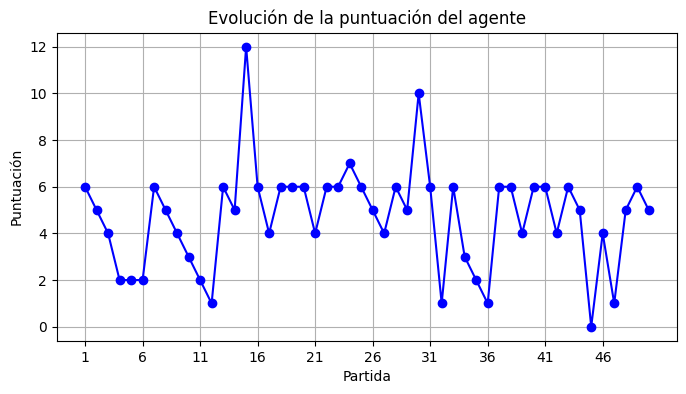

In [ ]:
# Mostramos gráficamente la evolución de las puntuaciones
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_partidas + 1), puntuaciones, marker='o', color='blue')
plt.title("Evolución de la puntuación del agente")
plt.xlabel("Partida")
plt.ylabel("Puntuación")
plt.xticks(range(1, num_partidas + 1, 5))
plt.grid(True)
plt.show()

## Aprendizaje obtenido

> A continuación se presentan las conclusiones y aprendizajes obtenidos durante el desarrollo de esta actividad, junto con una valoración personal del proceso.

Durante el desarrollo de esta actividad se ha comprendido el funcionamiento del Reinforcement Learning de forma práctica.
Se ha observado cómo un agente parte sin ningún conocimiento del juego y, progresivamente, a base de errores y recompensas, mejora su rendimiento.

Uno de los aspectos más destacables ha sido la importancia del tiempo de entrenamiento.
Con 100.000 timesteps el agente ya mostraba mejoras, pero con 500.000 timesteps y los wrappers optimizados la puntuación casi se duplicó.

Asimismo, se ha comprobado que técnicas como el frame stacking, los wrappers de Atari y el entrenamiento con múltiples entornos en paralelo tienen un impacto significativo en el resultado final.

Como conclusión, con un mayor tiempo de entrenamiento y más timesteps se podrían obtener resultados aún mejores, ya que a mayor número de intentos y errores, mayor es el aprendizaje obtenido.